# OBD-II Dataset Analysis

## Objective

This notebook presents the exploratory analysis of the OBD-II diagnostic dataset used in the AutoIntel AI – Intelligent Vehicle Diagnosis and Maintenance Assistant project.

The objective is to understand the structure, quality, and characteristics of the OBD-II diagnostic codes before constructing the knowledge base used for intelligent fault diagnosis.

The insights obtained during this analysis will support the preprocessing, knowledge base preparation, and AI-powered complaint analysis in subsequent project phases.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import files
# Upload CSV file
uploaded = files.upload()


Saving obd_codes.csv to obd_codes.csv


In [3]:
df = pd.read_csv("obd_codes.csv")

In [4]:
df.head()

,OBD_Code,Description
0,P0001,Fuel Volume Regulator A Control Circuit/Open
1,P0002,Fuel Volume Regulator A Control Circuit Perfor...
2,P0003,Fuel Volume Regulator A Control Circuit Low
3,P0004,Fuel Volume Regulator A Control Circuit High
4,P0005,Fuel Shutoff Valve A Control Circuit/Open


In [5]:
df.shape

(7389, 2)

In [6]:
df.columns

Index(['OBD_Code', 'Description'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7389 entries, 0 to 7388
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   OBD_Code     7389 non-null   object
 1   Description  7389 non-null   object
dtypes: object(2)
memory usage: 115.6+ KB


In [8]:
df.describe(include='all')

,OBD_Code,Description
count,7389,7389
unique,7387,7384
top,P3400,O2 Sensor Out of Range During Deceleration Ban...
freq,2,2


# Data Quality Assessment

The dataset is evaluated to assess its completeness, consistency, and suitability for analysis.

The following checks are performed:

- Missing values
- Duplicate records
- Duplicate OBD codes
- Dataset dimensions
- Data types

In [9]:
df.isnull().sum()

,0
OBD_Code,0
Description,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["OBD_Code"].duplicated().sum()

np.int64(2)

# Exploratory Data Analysis

The exploratory analysis focuses on understanding the distribution of diagnostic codes and identifying common characteristics of the fault descriptions.

The analysis provides useful insights for designing the OBD knowledge base in the next phase of the project.

In [12]:
print(df["OBD_Code"].nunique())

7387


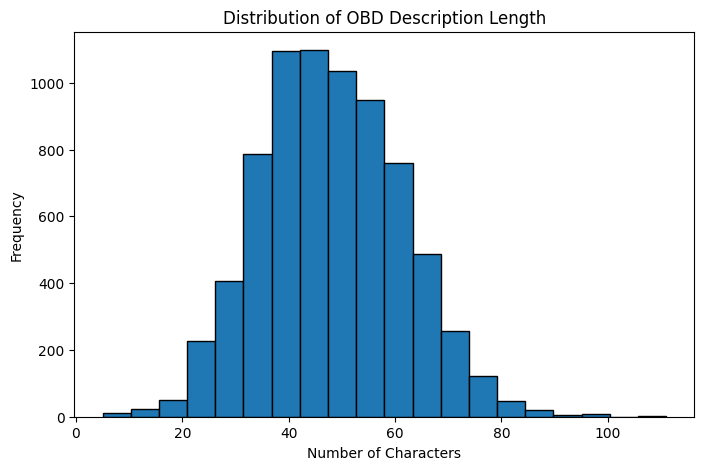

In [13]:
df["Description_Length"] = df["Description"].str.len()

plt.figure(figsize=(8,5))

plt.hist(df["Description_Length"], bins=20, edgecolor="black")

plt.title("Distribution of OBD Description Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

### Observations

- The distribution indicates that most OBD-II fault descriptions have a moderate character length, providing sufficient detail while remaining concise.
- Only a small number of descriptions are significantly longer or shorter than the average, suggesting consistent documentation across the dataset.
- The relatively uniform description lengths will facilitate future Natural Language Processing (NLP) tasks such as text embedding and similarity matching.

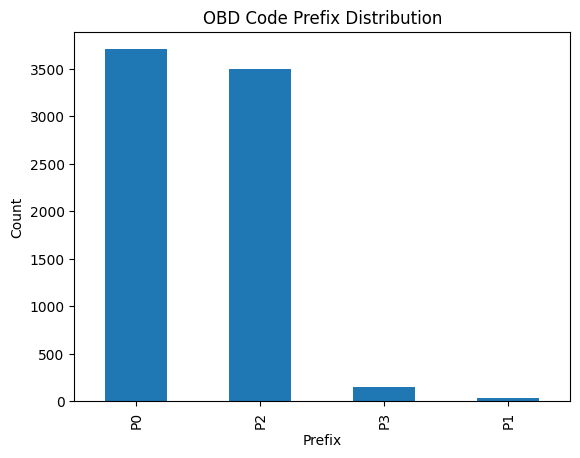

In [14]:
df["Prefix"] = df["OBD_Code"].str[:2]

df["Prefix"].value_counts().plot(kind="bar")

plt.title("OBD Code Prefix Distribution")

plt.xlabel("Prefix")

plt.ylabel("Count")

plt.show()

### Observations

- The dataset contains diagnostic codes across multiple OBD-II prefix categories, indicating broad coverage of powertrain-related faults.
- Standard (P0) and manufacturer-specific code groups are both represented, improving the diversity of the knowledge base.
- The distribution demonstrates that the dataset can support diagnosis for both generic and manufacturer-specific vehicle issues.

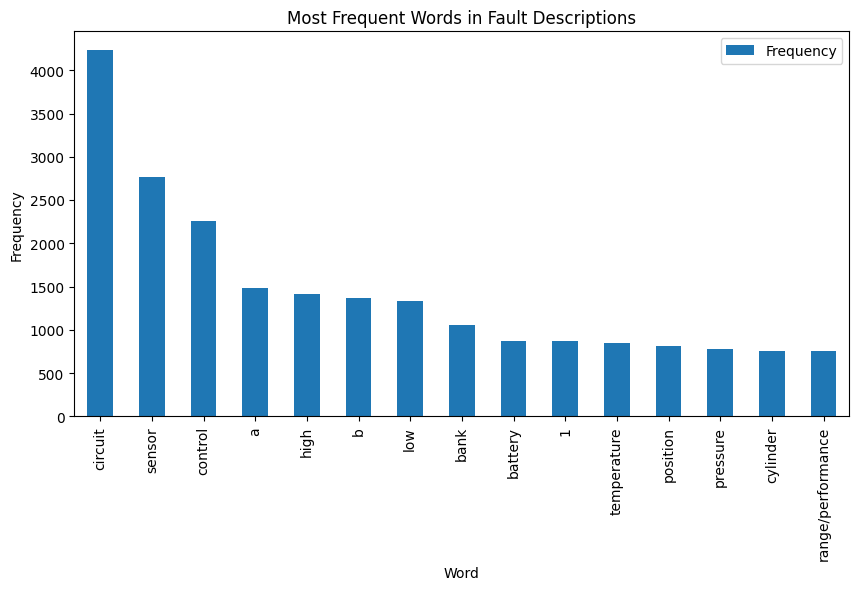

In [15]:
from collections import Counter

words = " ".join(df["Description"]).lower().split()

common = Counter(words).most_common(15)

common_df = pd.DataFrame(common, columns=["Word","Frequency"])

common_df.plot(
    x="Word",
    y="Frequency",
    kind="bar",
    figsize=(10,5)
)

plt.title("Most Frequent Words in Fault Descriptions")

plt.ylabel("Frequency")

plt.show()

### Observations

- Technical terms such as **Circuit**, **Sensor**, **Control**, and **Voltage** appear most frequently within the fault descriptions.
- The repeated occurrence of these keywords indicates that electrical and electronic system faults constitute a significant portion of the diagnostic dataset.
- These frequently occurring terms will be valuable during the development of keyword-based retrieval and semantic search modules in the AutoIntel AI system.

# Analysis Observations

The exploratory analysis revealed several important characteristics of the OBD-II dataset.

### Key Findings

- The dataset contains over 7,000 diagnostic codes, providing extensive coverage of powertrain-related faults.
- No missing values or duplicate records were identified, indicating good overall data quality.
- Fault descriptions vary in length but follow a consistent textual format.
- Certain technical terms such as "Circuit", "Sensor", "Control", and "Voltage" appear frequently, reflecting common diagnostic categories.
- The dataset provides a strong foundation for constructing the OBD knowledge base used in the AutoIntel AI diagnosis engine.

# Data Cleaning

Following the exploratory analysis, the dataset was standardized to ensure consistency before subsequent project phases.

The cleaning process included:

- Removing leading and trailing whitespace
- Standardizing OBD codes to uppercase
- Verifying data types
- Confirming the absence of missing values and duplicate records

Since the dataset was already well-structured, no major preprocessing was required and the exploratory analysis remains representative of the cleaned dataset.

In [16]:
# Create a copy of the original dataset
df_clean = df.copy()

# Remove leading and trailing whitespace
df_clean["OBD_Code"] = df_clean["OBD_Code"].str.strip()
df_clean["Description"] = df_clean["Description"].str.strip()

# Convert OBD codes to uppercase
df_clean["OBD_Code"] = df_clean["OBD_Code"].str.upper()

# Ensure string datatype
df_clean["OBD_Code"] = df_clean["OBD_Code"].astype(str)
df_clean["Description"] = df_clean["Description"].astype(str)

In [17]:
print("Missing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:", df_clean.duplicated().sum())

print("\nDuplicate OBD Codes:", df_clean["OBD_Code"].duplicated().sum())

df_clean.info()

Missing Values:
OBD_Code              0
Description           0
Description_Length    0
Prefix                0
dtype: int64

Duplicate Rows: 0

Duplicate OBD Codes: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7389 entries, 0 to 7388
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   OBD_Code            7389 non-null   object
 1   Description         7389 non-null   object
 2   Description_Length  7389 non-null   int64 
 3   Prefix              7389 non-null   object
dtypes: int64(1), object(3)
memory usage: 231.0+ KB


In [18]:
df_clean.to_csv("obd_codes_clean.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [20]:
from google.colab import files

files.download("obd_codes_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
df_clean.head()

,OBD_Code,Description,Description_Length,Prefix
0,P0001,Fuel Volume Regulator A Control Circuit/Open,44,P0
1,P0002,Fuel Volume Regulator A Control Circuit Perfor...,51,P0
2,P0003,Fuel Volume Regulator A Control Circuit Low,43,P0
3,P0004,Fuel Volume Regulator A Control Circuit High,44,P0
4,P0005,Fuel Shutoff Valve A Control Circuit/Open,41,P0


In [22]:
print(df_clean.shape)

(7389, 4)


# Cleaning Summary

The dataset required only minor preprocessing as it contained no missing values or duplicate records.

Formatting was standardized by removing unnecessary whitespace, converting OBD codes to uppercase, and ensuring consistent data types.

The cleaned dataset is suitable for exploratory analysis and provides a reliable foundation for the knowledge base construction planned in the next project phase.

# Week 1 Summary

The OBD-II dataset was successfully analyzed and evaluated for completeness, consistency, and overall quality.

The analysis included dataset inspection, data quality assessment, and exploratory data analysis of diagnostic codes and fault descriptions.

The dataset has been verified as suitable for the next project phase, where diagnostic codes will be standardized and transformed into a structured knowledge base with additional attributes such as category, severity, and fault descriptions.